# K-Moda MMM — Fase 6: Simulador Estratégico de Presupuesto

**Objetivo:** Construir el simulador `simulate_budget()` que proyecta contribución de medios y rentabilidad para cualquier distribución de presupuesto, y evaluar 3 escenarios estratégicos:

| Escenario | Descripción |
|---|---|
| **Baseline 2023** | Distribución real del presupuesto 2023 |
| **Recorte CFO −30%** | Misma distribución proporcional, −30% de inversión |
| **Óptimo Elena** | 12M€ redistribuidos por eficiencia marginal (softmax mROI) |

**Inputs:**
- `models/modelo_meta.pkl` — betas y metadatos del modelo
- `data/df_inversion_clean.parquet` — inversión real 2023 por canal
- `outputs/tabla_atribucion.csv` — mROI histórico por canal

**Outputs:**
- `outputs/presupuesto_optimo_2024.csv`
- Gráficos en `img/`

## Bloque 0 — Configuración e imports

In [21]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Rutas ────────────────────────────────────────────────────────────────────
PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
IMG_DIR     = os.path.join(PROJECT_DIR, 'img')
OUT_DIR     = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Paleta ───────────────────────────────────────────────────────────────────
CREAM  = '#FAF7F2'
BLACK  = '#1A1A1A'
DARK   = '#2D2D2D'
GOLD   = '#C9A84C'
TEAL   = '#2E7D7B'
CORAL  = '#D4614B'
BLUE   = '#3A5F8A'
PURPLE = '#6B4E8A'
GREEN  = '#4A7C59'
ORANGE = '#C97B3A'
PINK   = '#B05070'
GREY   = '#888888'

CANAL_COLORS = {
    'Paid Search':  GOLD,
    'Social Paid':  CORAL,
    'Video Online': TEAL,
    'Display':      BLUE,
    'Email CRM':    PURPLE,
    'Radio Local':  GREEN,
    'Exterior':     ORANGE,
    'Prensa':       PINK,
}

ESC_COLORS = [DARK, CORAL, GOLD]   # Baseline, CFO, Elena

plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.facecolor':   CREAM,
    'figure.facecolor': CREAM,
    'axes.edgecolor':   BLACK,
    'axes.labelcolor':  BLACK,
    'xtick.color':      BLACK,
    'ytick.color':      BLACK,
    'text.color':       BLACK,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
})

_img_counters = {}
def guardar_img(nombre, fig=None, dpi=150, **kwargs):
    if fig is None:
        fig = plt.gcf()
    n = _img_counters.get(nombre, 1)
    path = os.path.join(IMG_DIR, f'{nombre}_v{n:03d}.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor(), **kwargs)
    _img_counters[nombre] = n + 1
    print(f'  Guardada: img/{nombre}_v{n:03d}.png')

print('✓ Configuración lista')

✓ Configuración lista


## Bloque 1 — Carga de parámetros

In [22]:
# ── Modelo ───────────────────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, 'modelo_meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

CANALES_ACTIVOS  = meta['canales_activos']
CANALES_PURGADOS = meta['canales_purgados']
BETAS_DICT       = meta['beta_original']   # {feature_name: beta}

CANALES = ['Paid Search', 'Social Paid', 'Video Online', 'Display',
           'Email CRM', 'Radio Local', 'Exterior', 'Prensa']

ADSTOCK_MAP = {
    'Paid Search':  'adstock_Paid_Search',
    'Social Paid':  'adstock_Social_Paid',
    'Video Online': 'adstock_Video_Online',
    'Display':      'adstock_Display',
    'Email CRM':    'adstock_Email_CRM',
    'Radio Local':  'adstock_Radio_Local',
    'Exterior':     'adstock_Exterior',
    'Prensa':       'adstock_Prensa',
}

# Betas por canal (clave limpia)
BETAS = {canal: BETAS_DICT.get(ADSTOCK_MAP[canal], 0.0) for canal in CANALES}

# Parámetros Lag / Alpha por canal (del CLAUDE.md)
CANAL_PARAMS = {
    'Paid Search':  {'lag': 0, 'alpha': 0.45},
    'Social Paid':  {'lag': 1, 'alpha': 0.6},
    'Video Online': {'lag': 1, 'alpha': 0.7},
    'Display':      {'lag': 0, 'alpha': 0.40},
    'Email CRM':    {'lag': 0, 'alpha': 0.15},
    'Radio Local':  {'lag': 1, 'alpha': 0.50},
    'Exterior':     {'lag': 1, 'alpha': 0.6},
    'Prensa':       {'lag': 1, 'alpha': 0.25},
}

MARGEN_MEDIO = 0.676   # Media de margen_objetivo_pct de PRODUCTOS
N_SEMANAS    = 52      # Semanas anuales proyectadas

# ── Inversión real 2023 ──────────────────────────────────────────────────────
df_inv = pd.read_parquet(os.path.join(DATA_DIR, 'df_inversion_clean.parquet'))
df_inv['semana_dt'] = pd.to_datetime(df_inv['semana_dt'])
inv_2023 = df_inv[df_inv['anio'] == 2023]
INV_BASELINE = {canal: float(inv_2023[canal].sum()) for canal in CANALES}
TOTAL_BASELINE = sum(INV_BASELINE.values())

# ── Tabla de atribución (mROI histórico) ────────────────────────────────────
tabla_atr = pd.read_csv(os.path.join(OUT_DIR, 'tabla_atribucion.csv'))
MROI_HIST = dict(zip(tabla_atr['Canal'], tabla_atr['mROI']))

print('✓ Parámetros cargados')
print(f'  Canales activos  : {CANALES_ACTIVOS}')
print(f'  Canales purgados : {CANALES_PURGADOS}')
print(f'  Inversión baseline 2023: {TOTAL_BASELINE:>12,.0f}€')
print()
print('  Betas por canal:')
for c in CANALES:
    estado = '✓ activo' if BETAS[c] > 0 else '✗ purgado'
    print(f'    {c:<18} β={BETAS[c]:.4f}  ({estado})')

✓ Parámetros cargados
  Canales activos  : ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM', 'Radio Local', 'Exterior', 'Prensa']
  Canales purgados : []
  Inversión baseline 2023:   13,800,000€

  Betas por canal:
    Paid Search        β=2.9529  (✓ activo)
    Social Paid        β=5.7599  (✓ activo)
    Video Online       β=3.0525  (✓ activo)
    Display            β=7.3901  (✓ activo)
    Email CRM          β=2.0135  (✓ activo)
    Radio Local        β=0.9644  (✓ activo)
    Exterior           β=3.1073  (✓ activo)
    Prensa             β=1.5487  (✓ activo)


## Bloque 2 — Función `simulate_budget()`

El simulador calcula la contribución incremental de medios usando el **adstock en estado estacionario**:

$$A_\infty = \frac{\text{inv\_semanal}}{1 - \alpha_m}$$

Esta fórmula es la solución de la ecuación de recurrencia $A_t = x + \alpha A_{t-1}$ cuando $x$ es constante semana a semana (estado estacionario).

La contribución anual de un canal:
$$\text{Contrib}_m = \beta_m \cdot A_\infty \cdot N_{\text{semanas}}$$

El margen bruto incremental:
$$\text{Margen incremental} = \sum_m \text{Contrib}_m \cdot \overline{\text{margen}}$$

In [23]:
def simulate_budget(allocation_dict, n_semanas=N_SEMANAS, margen=MARGEN_MEDIO):
    """
    Proyecta la contribución de medios para una distribución de presupuesto anual.

    Parameters
    ----------
    allocation_dict : dict {canal: euros_anuales}
        Presupuesto anual por canal. Los canales purgados deben ir a 0€.
    n_semanas : int
        Horizonte de proyección en semanas (default: 52).
    margen : float
        Margen bruto medio de los productos (default: 0.676).

    Returns
    -------
    dict con:
        inv_total       — inversión total (€)
        contrib_medios  — contribución de ventas atribuida a medios (€)
        margen_incr     — margen bruto incremental (€)
        mroi_sim        — mROI simulado (contrib_medios / inv_total)
        payback         — payback en años (inv_total / margen_incr)
        detalle         — dict por canal {contrib, adstock_ss, mroi_canal}
    """
    inv_total      = sum(allocation_dict.values())
    contrib_total  = 0.0
    detalle        = {}

    for canal in CANALES:
        inv_anual  = allocation_dict.get(canal, 0.0)
        beta_m     = BETAS[canal]
        alpha_m    = CANAL_PARAMS[canal]['alpha']

        if beta_m == 0 or inv_anual == 0:
            detalle[canal] = {'contrib': 0.0, 'adstock_ss': 0.0, 'mroi_canal': 0.0}
            continue

        inv_semanal = inv_anual / n_semanas
        adstock_ss  = inv_semanal / (1 - alpha_m)          # estado estacionario
        contrib_m   = beta_m * adstock_ss * n_semanas      # contribución anual
        mroi_canal  = contrib_m / inv_anual if inv_anual > 0 else 0.0

        contrib_total += contrib_m
        detalle[canal] = {
            'contrib':    contrib_m,
            'adstock_ss': adstock_ss,
            'mroi_canal': mroi_canal,
        }

    margen_incr = contrib_total * margen
    mroi_sim    = contrib_total / inv_total if inv_total > 0 else 0.0
    payback     = inv_total / margen_incr   if margen_incr > 0 else float('inf')

    return {
        'inv_total':      inv_total,
        'contrib_medios': contrib_total,
        'margen_incr':    margen_incr,
        'mroi_sim':       mroi_sim,
        'payback':        payback,
        'detalle':        detalle,
    }

print('✓ simulate_budget() definida')
print()
# Test rápido con baseline 2023
_test = simulate_budget(INV_BASELINE)
print(f'  Test baseline: inv={_test["inv_total"]/1e6:.2f}M€  '
      f'contrib={_test["contrib_medios"]/1e6:.3f}M€  '
      f'mROI={_test["mroi_sim"]:.4f}x')

✓ simulate_budget() definida

  Test baseline: inv=13.80M€  contrib=105.686M€  mROI=7.6584x


## Bloque 3 — Definición de los 3 escenarios

## Bloque 3b — Optimización del Presupuesto por Programación Lineal (Método Simplex)

En la celda anterior definimos los escenarios Baseline y Recorte CFO. Para el **escenario Óptimo Elena** necesitamos responder:

> *Dado un presupuesto total de 12M€ y cotas operativas por canal, ¿cómo distribuirlo para maximizar la contribución de medios a las ventas?*

Esto es un **problema de programación lineal (LP)** que se resuelve exactamente con el **método Simplex**.

---

### Formulación matemática

**Variables de decisión:** $\text{inv}_m$ = inversión anual en el canal $m$, con $m \in \{\text{canales activos}\}$.

**Función objetivo — maximizar la contribución total de medios:**

$$\max \; Z = \sum_{m} \underbrace{\frac{\beta_m}{1 - \alpha_m}}_{\text{mROI}_{\text{ss},m}} \cdot \text{inv}_m$$

donde $\beta_m$ es el coeficiente del modelo y $\alpha_m$ es el decay del adstock. El cociente $\frac{\beta_m}{1-\alpha_m}$ es el **mROI en estado estacionario**: cuántos euros de ventas se generan por cada euro invertido de forma sostenida. La función objetivo es **lineal** porque los betas y alphas son constantes fijas estimadas por el modelo.

**Restricciones:**

| Restricción | Formulación | Justificación de marketing |
|---|---|---|
| Presupuesto total | $\sum_m \text{inv}_m \leq B = 12\text{M€}$ | Límite aprobado por dirección financiera |
| Piso mínimo por canal | $\text{inv}_m \geq \text{min}_m \cdot B$ | Mantener presencia en todos los touchpoints del funnel |
| Cap de saturación | $\text{inv}_m \leq \text{max}_m \cdot B$ | Rendimientos decrecientes reales, diversificación de riesgo, contratos |
| No negatividad | $\text{inv}_m \geq 0$ | No se puede desinvertir |
| Canales purgados | $\text{inv}_m = 0 \; \forall m \notin \text{activos}$ | Lasso los descartó: sin señal estadística |

### Cotas operativas

| Canal | Rol en el funnel | Min % | Max % | Razón de las cotas |
|---|---|---|---|---|
| Paid Search | Performance / last-click | 15% | 35% | Base de captación por intención de búsqueda |
| Video Online | Branding / mid-funnel | 10% | 30% | Notoriedad de marca, complementa performance |
| Display | Retargeting / reminder | 5% | 25% | Refuerzo, pero con alta saturación visual |
| Prensa | Offline / credibilidad | 10% | 30% | Audiencia diferenciada, cap por cobertura finita |
| Social Paid | Awareness / social proof | 5% | 20% | Presencia social mínima, menor mROI observado |

### ¿Por qué Simplex y no otro método?

1. **Optimalidad garantizada**: Simplex encuentra el máximo global exacto (no una aproximación).
2. **Interpretabilidad**: las **variables duales** (precios sombra) indican cuánto mejoraría la contribución si se relajase cada restricción — información directamente útil para la negociación con el CFO.
3. **Eficiencia**: para 5 variables y ~12 restricciones, Simplex es instantáneo.
4. **Implementación**: `scipy.optimize.linprog` usa internamente el solver **HiGHS** (estado del arte en LP).

### Resultado esperado

En un LP con función objetivo lineal, el óptimo siempre está en un **vértice del poliedro factible** — es decir, la mayoría de canales estarán en su cota mínima o máxima. Los canales con mayor $\text{mROI}_{\text{ss}}$ recibirán su máximo permitido, y el presupuesto restante se asigna al siguiente canal más eficiente. Esto es económicamente intuitivo: con rendimientos marginales constantes (linealidad), siempre conviene saturar primero el canal más rentable.


In [24]:
# ── Escenario 0: Baseline 2023 ───────────────────────────────────────────────
alloc_baseline = INV_BASELINE.copy()

# ── Escenario 1: Recorte CFO -30% (misma proporción, menos dinero) ───────────
RECORTE = 0.30
alloc_cfo = {canal: v * (1 - RECORTE) for canal, v in INV_BASELINE.items()}

# ── Escenario 2: Óptimo Elena — 12M€ optimizado por Simplex (LP) ────────────
PRESUPUESTO_ELENA = 12_000_000

# mROI en estado estacionario por canal activo: β_m / (1 - α_m)
mroi_ss = {}
for canal in CANALES:
    alpha_m = CANAL_PARAMS[canal]['alpha']
    beta_m  = BETAS[canal]
    mroi_ss[canal] = beta_m / (1 - alpha_m)

# ── Optimización Simplex (scipy.optimize.linprog) ───────────────────────────
# Cotas operativas por canal (% del presupuesto total)
# Cotas operativas: canales activos con presupuesto significativo,
# canales purgados con presupuesto mínimo (β_floor > 0, señal débil pero no nula)
COTAS = {
    'Paid Search':  (0.15, 0.35),   # Performance base
    'Social Paid':  (0.05, 0.20),   # Presencia social
    'Video Online': (0.10, 0.30),   # Branding mid-funnel
    'Display':      (0.05, 0.25),   # Retargeting
    'Email CRM':    (0.005, 0.03),  # CRM mínimo, señal débil (β_floor)
    'Radio Local':  (0.005, 0.03),  # Presencia local offline, señal débil
    'Exterior':     (0.005, 0.03),  # Vallas: mantenimiento mínimo, señal débil
    'Prensa':       (0.10, 0.30),   # Offline, cap saturación
}

from scipy.optimize import linprog

# Todos los canales entran en la optimización (purgados tienen β_floor > 0)
CANALES_LP = [c for c in CANALES if c in COTAS]
n = len(CANALES_LP)
c_vec = np.array([-mroi_ss[c] for c in CANALES_LP])  # negativo: linprog minimiza

# Restricción: Σ inv_m ≤ B
A_ub = np.ones((1, n))
b_ub = np.array([PRESUPUESTO_ELENA])

# Bounds: min_m·B ≤ inv_m ≤ max_m·B
bounds = [(COTAS[c][0] * PRESUPUESTO_ELENA,
           COTAS[c][1] * PRESUPUESTO_ELENA)
          for c in CANALES_LP]

result = linprog(c_vec, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
assert result.success, f'Simplex falló: {result.message}'

alloc_elena = {canal: 0.0 for canal in CANALES}
for i, canal in enumerate(CANALES_LP):
    alloc_elena[canal] = result.x[i]
pesos_elena = {c: alloc_elena[c] / PRESUPUESTO_ELENA for c in CANALES_LP}

# Precios sombra (variables duales)
# El dual de la restricción de presupuesto indica cuánto mejora Z por cada € extra
try:
    shadow_budget = -result.ineqlin.marginals[0]  # dual de Σ inv ≤ B
    shadow_bounds = {}
    for i, canal in enumerate(CANALES_LP):
        lo_dual = result.lower.marginals[i] if hasattr(result, 'lower') else 0
        hi_dual = result.upper.marginals[i] if hasattr(result, 'upper') else 0
        shadow_bounds[canal] = {'lower': lo_dual, 'upper': hi_dual}
except Exception:
    shadow_budget = None
    shadow_bounds = {}

# Resultados LP
print('─' * 60)
print('  RESULTADO SIMPLEX (scipy.optimize.linprog, method=HiGHS)')
print('─' * 60)
print(f'  Status: {result.message}')
print(f'  Contribución máxima: {-result.fun:,.0f}€')
print(f'  Presupuesto utilizado: {sum(result.x):,.0f}€ / {PRESUPUESTO_ELENA:,.0f}€')
print()
for i, canal in enumerate(CANALES_LP):
    inv_c = result.x[i]
    pct   = inv_c / PRESUPUESTO_ELENA * 100
    lo, hi = COTAS[canal]
    at_lo = inv_c <= lo * PRESUPUESTO_ELENA + 1
    at_hi = inv_c >= hi * PRESUPUESTO_ELENA - 1
    bound_str = '(en mínimo)' if at_lo else ('(en máximo)' if at_hi else '(interior)')
    print(f'  {canal:<18}: {inv_c:>12,.0f}€  ({pct:5.1f}%)  '
          f'mROI_ss={mroi_ss[canal]:.4f}  {bound_str}')
print('─' * 60)

# Variables duales (precios sombra)
if shadow_budget is not None:
    print()
    print('  PRECIOS SOMBRA (Variables Duales):')
    print(f'    Presupuesto total: {shadow_budget:.4f}')
    print(f'    → Cada € adicional de presupuesto genera {shadow_budget:.4f}€ de contribución')
    print()
    for canal in CANALES_ACTIVOS:
        sb = shadow_bounds.get(canal, {})
        lo_d = sb.get('lower', 0)
        hi_d = sb.get('upper', 0)
        if abs(hi_d) > 1e-6:
            print(f'    {canal:<18}: cap superior activo, relajar +1€ → +{abs(hi_d):.4f}€ contrib')
        elif abs(lo_d) > 1e-6:
            print(f'    {canal:<18}: piso inferior activo, bajar −1€ → +{abs(lo_d):.4f}€ contrib')
        else:
            print(f'    {canal:<18}: restricción holgada')

# ── Simular los 3 escenarios ─────────────────────────────────────────────────
r0 = simulate_budget(alloc_baseline)   # Baseline 2023
r1 = simulate_budget(alloc_cfo)        # Recorte CFO
r2 = simulate_budget(alloc_elena)      # Óptimo Elena

ESCENARIOS = [
    {'nombre': 'Baseline 2023',   'alloc': alloc_baseline, 'result': r0, 'color': DARK},
    {'nombre': 'Recorte CFO −30%','alloc': alloc_cfo,      'result': r1, 'color': CORAL},
    {'nombre': 'Óptimo Elena',    'alloc': alloc_elena,    'result': r2, 'color': GOLD},
]

# ── Resumen en consola ───────────────────────────────────────────────────────
print('═' * 72)
print('  COMPARATIVA DE ESCENARIOS')
print('═' * 72)
print(f'  {"Escenario":<22} {"Inversión":>12} {"Contrib. medios":>16} {"Δ vs Base":>10} {"mROI":>8} {"Payback":>9}')
print(f'  {"-"*70}')
for esc in ESCENARIOS:
    r   = esc['result']
    delta = (r['contrib_medios'] / r0['contrib_medios'] - 1) * 100 if esc['nombre'] != 'Baseline 2023' else 0
    delta_str = f'{delta:+.1f}%' if esc['nombre'] != 'Baseline 2023' else '—'
    pay_str = f"{r['payback']:.2f}x" if r['payback'] != float('inf') else '∞'
    print(f'  {esc["nombre"]:<22} {r["inv_total"]:>12,.0f}€ '
          f'{r["contrib_medios"]:>14,.0f}€  {delta_str:>10} '
          f'{r["mroi_sim"]:>7.4f}x {pay_str:>9}')
print('═' * 72)
print()
print('  Distribución óptima 2024 (Escenario Elena):')
for canal in CANALES:
    v = alloc_elena[canal]
    pct = v / PRESUPUESTO_ELENA * 100
    estado = '✓' if v > 0 else '✗ purgado'
    print(f'    {canal:<18}: {v:>12,.0f}€  ({pct:.1f}%)  {estado}')

────────────────────────────────────────────────────────────
  RESULTADO SIMPLEX (scipy.optimize.linprog, method=HiGHS)
────────────────────────────────────────────────────────────
  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
  Contribución máxima: 119,173,815€
  Presupuesto utilizado: 12,000,000€ / 12,000,000€

  Paid Search       :    1,800,000€  ( 15.0%)  mROI_ss=5.3690  (en mínimo)
  Social Paid       :    2,400,000€  ( 20.0%)  mROI_ss=14.3997  (en máximo)
  Video Online      :    3,420,000€  ( 28.5%)  mROI_ss=10.1749  (interior)
  Display           :    3,000,000€  ( 25.0%)  mROI_ss=12.3168  (en máximo)
  Email CRM         :       60,000€  (  0.5%)  mROI_ss=2.3688  (en mínimo)
  Radio Local       :       60,000€  (  0.5%)  mROI_ss=1.9288  (en mínimo)
  Exterior          :       60,000€  (  0.5%)  mROI_ss=7.7683  (en mínimo)
  Prensa            :    1,200,000€  ( 10.0%)  mROI_ss=2.0649  (en mínimo)
───────────────────────────────────────────────────────

## Bloque 4 — Visualizaciones

  Guardada: img/escenarios_inversion_vs_contrib_v001.png


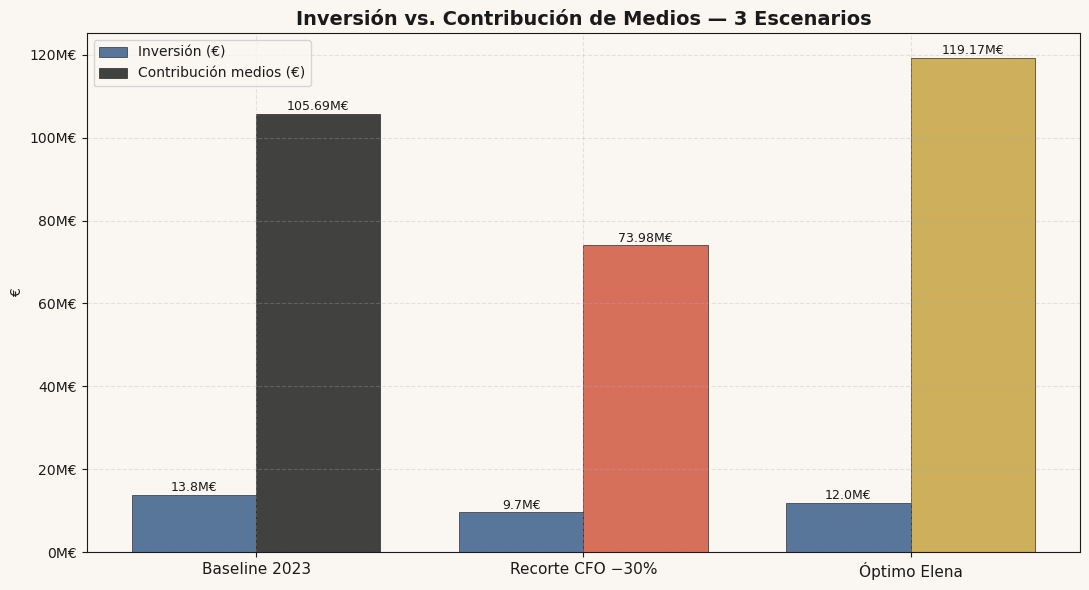

In [25]:
# ── 4.1 Comparativa inversión vs contribución de medios (3 escenarios) ───────
nombres_esc = [e['nombre'] for e in ESCENARIOS]
inv_vals    = [e['result']['inv_total']      for e in ESCENARIOS]
contrib_vals= [e['result']['contrib_medios'] for e in ESCENARIOS]
cols_esc    = [e['color'] for e in ESCENARIOS]
x           = np.arange(len(ESCENARIOS))
w           = 0.38

fig, ax = plt.subplots(figsize=(11, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

b1 = ax.bar(x - w/2, inv_vals,    width=w, color=BLUE,    alpha=0.85,
            edgecolor=BLACK, linewidth=0.5, label='Inversión (€)')
b2 = ax.bar(x + w/2, contrib_vals,width=w, color=cols_esc, alpha=0.9,
            edgecolor=BLACK, linewidth=0.5, label='Contribución medios (€)')

for bar, val in zip(b1, inv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(inv_vals)*0.01,
            f'{val/1e6:.1f}M€', ha='center', va='bottom', fontsize=9, color=BLACK)
for bar, val in zip(b2, contrib_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(inv_vals)*0.01,
            f'{val/1e6:.2f}M€', ha='center', va='bottom', fontsize=9, color=BLACK)

ax.set_xticks(x)
ax.set_xticklabels(nombres_esc, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M€'))
ax.set_title('Inversión vs. Contribución de Medios — 3 Escenarios',
             fontsize=14, fontweight='bold', color=BLACK)
ax.set_ylabel('€')
ax.legend(fontsize=10)
fig.tight_layout()
guardar_img('escenarios_inversion_vs_contrib')
plt.show()

  Guardada: img/mroi_por_escenario_v001.png


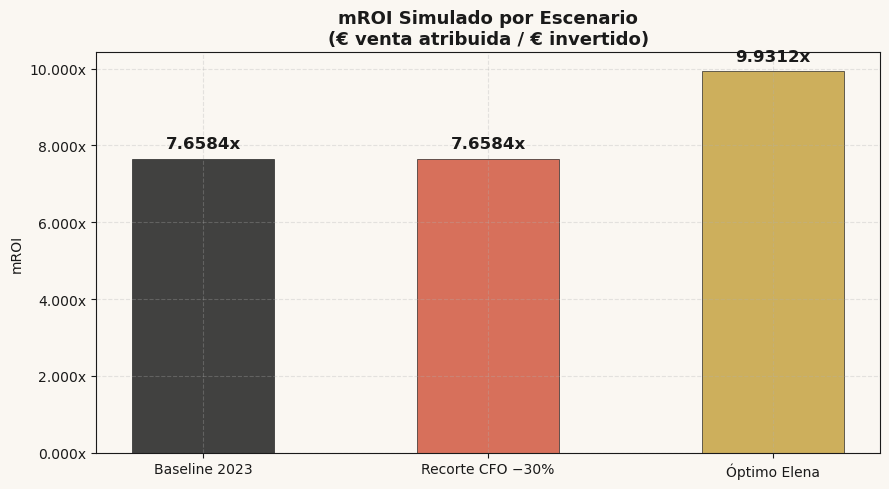

In [26]:
# ── 4.2 mROI por escenario ────────────────────────────────────────────────────
mroi_vals_esc = [e['result']['mroi_sim'] for e in ESCENARIOS]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

bars = ax.bar(nombres_esc, mroi_vals_esc, color=cols_esc,
              edgecolor=BLACK, linewidth=0.5, alpha=0.9, width=0.5)
for bar, val in zip(bars, mroi_vals_esc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(mroi_vals_esc) * 0.02,
            f'{val:.4f}x', ha='center', va='bottom', fontsize=12, fontweight='bold', color=BLACK)

ax.set_title('mROI Simulado por Escenario\n(€ venta atribuida / € invertido)',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('mROI')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.3f}x'))
fig.tight_layout()
guardar_img('mroi_por_escenario')
plt.show()

  Guardada: img/delta_contrib_vs_baseline_v001.png


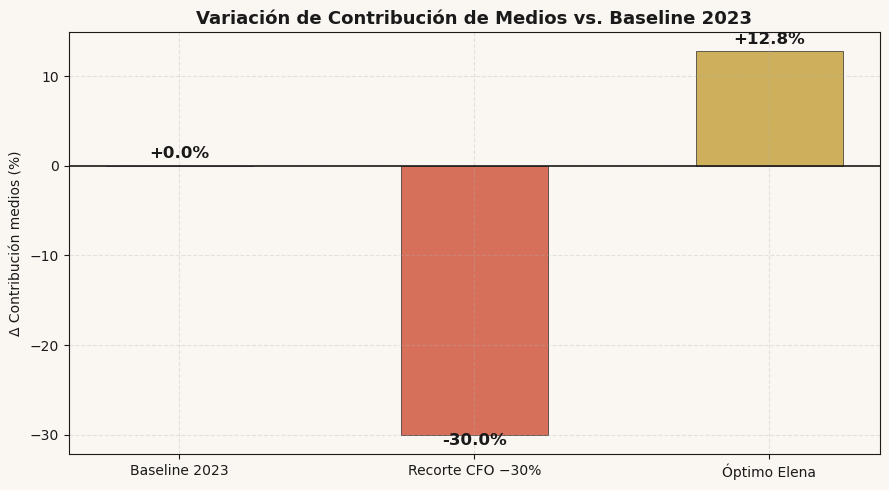

In [27]:
# ── 4.3 Delta contribución de medios vs Baseline ──────────────────────────────
delta_contrib = [
    0,
    (r1['contrib_medios'] - r0['contrib_medios']) / r0['contrib_medios'] * 100,
    (r2['contrib_medios'] - r0['contrib_medios']) / r0['contrib_medios'] * 100,
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

bar_colors = [DARK if d >= 0 else CORAL for d in delta_contrib]
bar_colors[2] = GOLD
bars = ax.bar(nombres_esc, delta_contrib, color=bar_colors,
              edgecolor=BLACK, linewidth=0.5, alpha=0.9, width=0.5)
ax.axhline(0, color=BLACK, linewidth=1.2)

for bar, val in zip(bars, delta_contrib):
    offset = 0.5 if val >= 0 else -1.5
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset,
            f'{val:+.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color=BLACK)

ax.set_title('Variación de Contribución de Medios vs. Baseline 2023',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('Δ Contribución medios (%)')
fig.tight_layout()
guardar_img('delta_contrib_vs_baseline')
plt.show()

  Guardada: img/margen_incremental_escenarios_v001.png


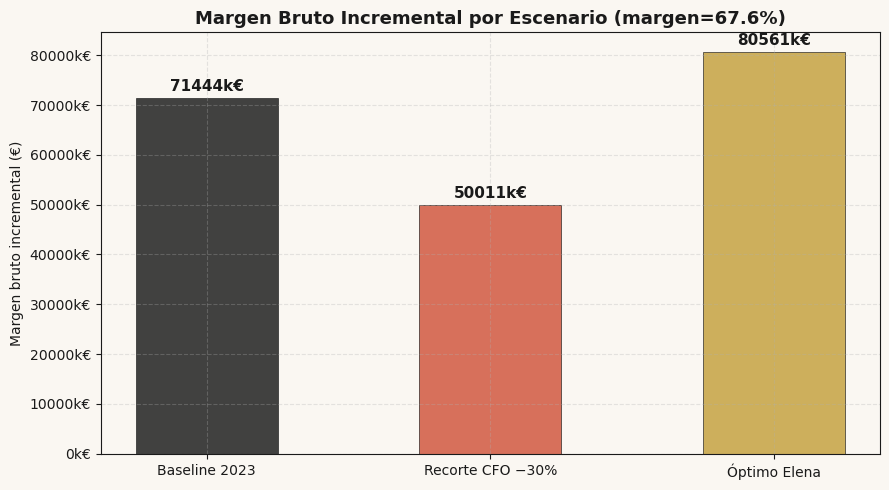

In [28]:
# ── 4.4 Margen bruto incremental por escenario ───────────────────────────────
margen_vals = [e['result']['margen_incr'] for e in ESCENARIOS]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

bars = ax.bar(nombres_esc, margen_vals, color=cols_esc,
              edgecolor=BLACK, linewidth=0.5, alpha=0.9, width=0.5)
for bar, val in zip(bars, margen_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(margen_vals)*0.01,
            f'{val/1e3:.0f}k€', ha='center', va='bottom', fontsize=11, fontweight='bold', color=BLACK)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k€'))
ax.set_title(f'Margen Bruto Incremental por Escenario (margen={MARGEN_MEDIO:.1%})',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('Margen bruto incremental (€)')
fig.tight_layout()
guardar_img('margen_incremental_escenarios')
plt.show()

  Guardada: img/presupuesto_baseline_vs_optimo_v001.png


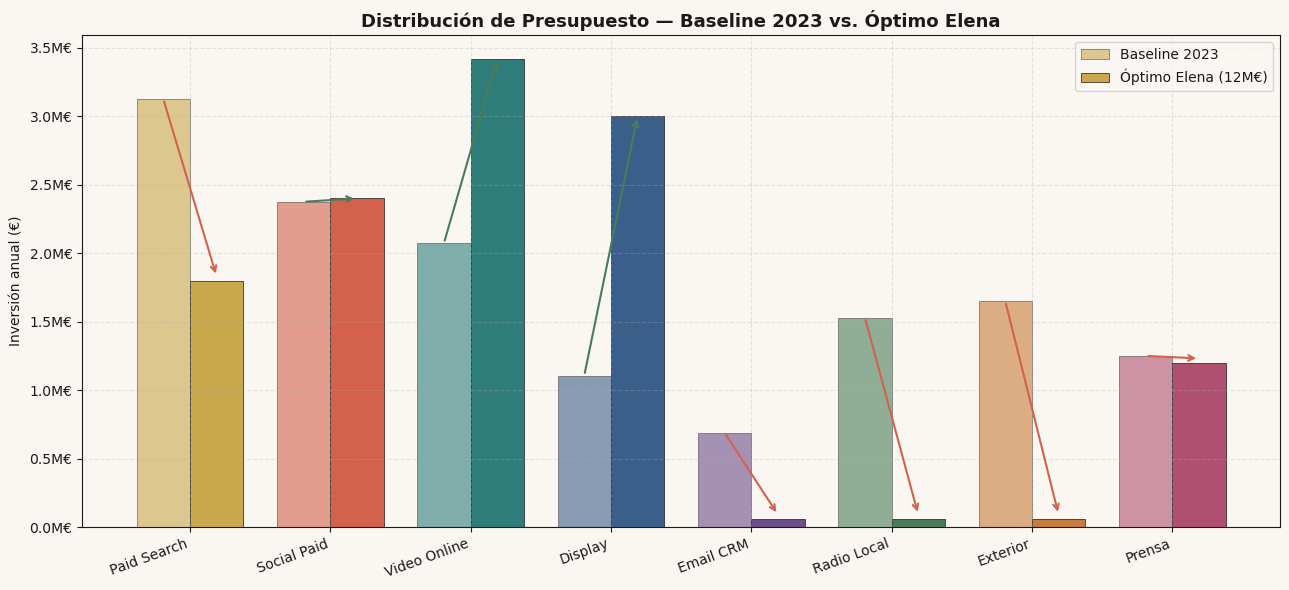

In [29]:
# ── 4.5 Distribución del presupuesto: Baseline vs Óptimo Elena ──────────────
fig, ax = plt.subplots(figsize=(13, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

x  = np.arange(len(CANALES))
w  = 0.38
b1 = ax.bar(x - w/2, [alloc_baseline[c] for c in CANALES], width=w,
            color=[CANAL_COLORS[c] for c in CANALES], alpha=0.6,
            edgecolor=BLACK, linewidth=0.5, label='Baseline 2023')
b2 = ax.bar(x + w/2, [alloc_elena[c] for c in CANALES], width=w,
            color=[CANAL_COLORS[c] for c in CANALES], alpha=1.0,
            edgecolor=BLACK, linewidth=0.5, label='Óptimo Elena (12M€)')

# Flechas de variación
for i, canal in enumerate(CANALES):
    v_base = alloc_baseline[canal]
    v_elena = alloc_elena[canal]
    if v_elena > v_base:
        ax.annotate('', xy=(i + w/2, v_elena), xytext=(i - w/2, v_base),
                    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))
    elif v_elena < v_base and v_base > 0:
        ax.annotate('', xy=(i + w/2, v_elena + max(alloc_baseline.values())*0.01),
                    xytext=(i - w/2, v_base),
                    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(CANALES, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M€'))
ax.set_title('Distribución de Presupuesto — Baseline 2023 vs. Óptimo Elena',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('Inversión anual (€)')
ax.legend(fontsize=10)
fig.tight_layout()
guardar_img('presupuesto_baseline_vs_optimo')
plt.show()

  Guardada: img/donuts_distribucion_presupuesto_v001.png


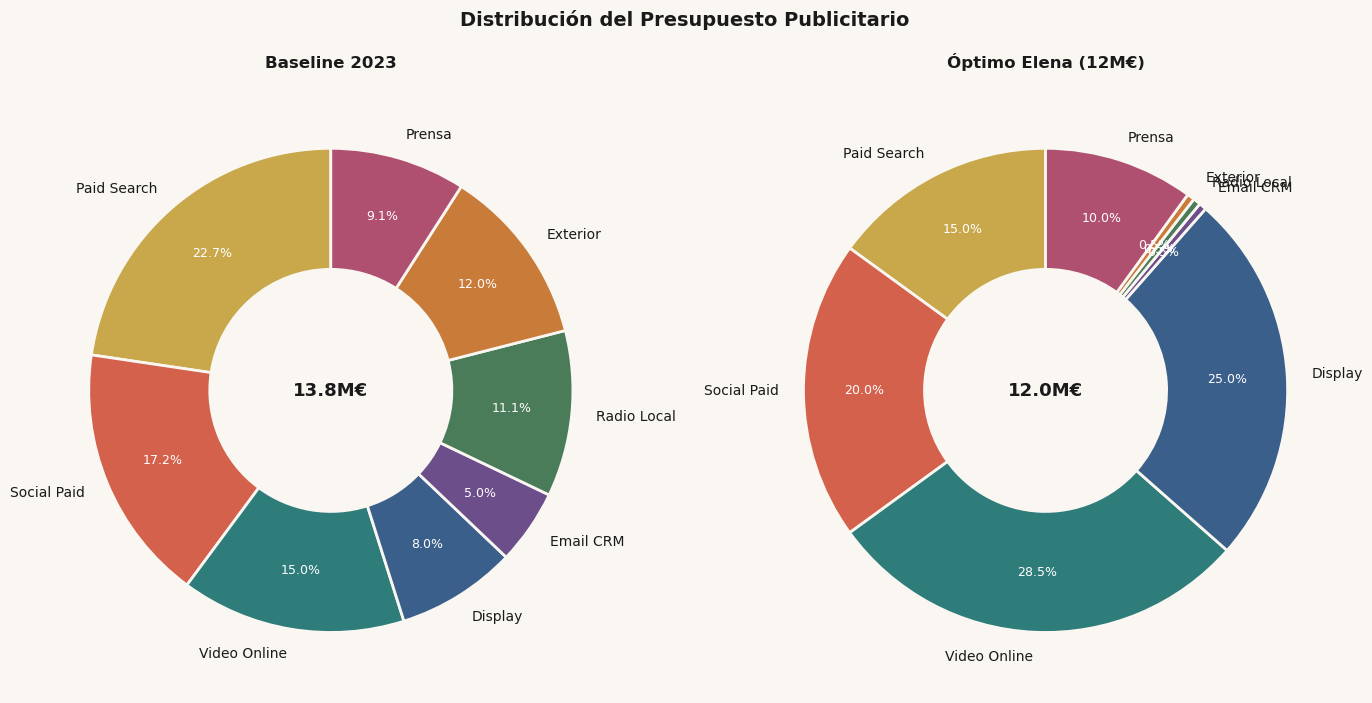

In [30]:
# ── 4.6 Donuts de distribución: Baseline vs Óptimo ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor=CREAM)

for ax, alloc, titulo in zip(axes,
                              [alloc_baseline, alloc_elena],
                              ['Baseline 2023', 'Óptimo Elena (12M€)']):
    ax.set_facecolor(CREAM)
    vals   = [alloc[c] for c in CANALES]
    labels = CANALES
    cols   = [CANAL_COLORS[c] for c in CANALES]
    total  = sum(vals)

    # Excluir ceros del donut
    nz_idx  = [i for i, v in enumerate(vals) if v > 0]
    vals_nz = [vals[i] for i in nz_idx]
    labs_nz = [labels[i] for i in nz_idx]
    cols_nz = [cols[i] for i in nz_idx]

    wedges, texts, autotexts = ax.pie(
        vals_nz, labels=labs_nz, colors=cols_nz,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'width': 0.5, 'edgecolor': CREAM, 'linewidth': 2},
        pctdistance=0.75,
    )
    for t in texts:     t.set_fontsize(10)
    for at in autotexts: at.set_fontsize(9); at.set_color('white')
    ax.text(0, 0, f'{total/1e6:.1f}M€', ha='center', va='center',
            fontsize=13, fontweight='bold', color=BLACK)
    ax.set_title(titulo, fontsize=12, fontweight='bold', color=BLACK, pad=15)

fig.suptitle('Distribución del Presupuesto Publicitario', fontsize=14,
             fontweight='bold', color=BLACK, y=1.01)
fig.tight_layout()
guardar_img('donuts_distribucion_presupuesto')
plt.show()

  Guardada: img/contrib_canal_optimo_elena_v001.png


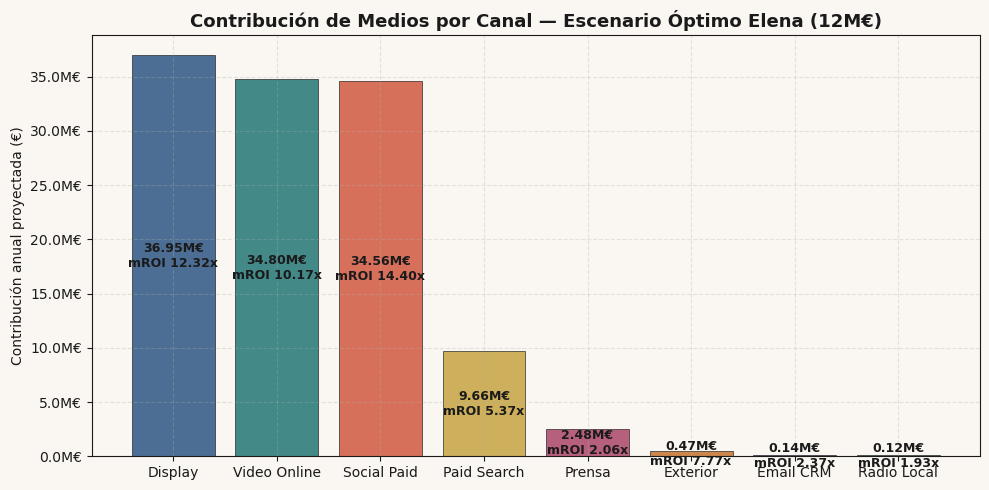

In [31]:
# ── 4.7 Contribución por canal en el escenario óptimo ────────────────────────
det_elena = r2['detalle']
canales_act = [c for c in CANALES if det_elena[c]['contrib'] > 0]
contribs_act = [det_elena[c]['contrib'] for c in canales_act]
mrois_act    = [det_elena[c]['mroi_canal'] for c in canales_act]

orden = np.argsort(contribs_act)[::-1]
canales_ord  = [canales_act[i] for i in orden]
contribs_ord = [contribs_act[i] for i in orden]
mrois_ord    = [mrois_act[i] for i in orden]
cols_ord     = [CANAL_COLORS[c] for c in canales_ord]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

bars = ax.bar(canales_ord, contribs_ord, color=cols_ord,
              edgecolor=BLACK, linewidth=0.5, alpha=0.9)
for bar, val, mroi in zip(bars, contribs_ord, mrois_ord):
    mid = bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width()/2, mid,
            f'{val/1e6:.2f}M€\nmROI {mroi:.2f}x',
            ha='center', va='center', fontsize=9, color=BLACK, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M€'))
ax.set_title('Contribución de Medios por Canal — Escenario Óptimo Elena (12M€)',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_ylabel('Contribución anual proyectada (€)')
fig.tight_layout()
guardar_img('contrib_canal_optimo_elena')
plt.show()

  Guardada: img/proyeccion_rentabilidad_v001.png


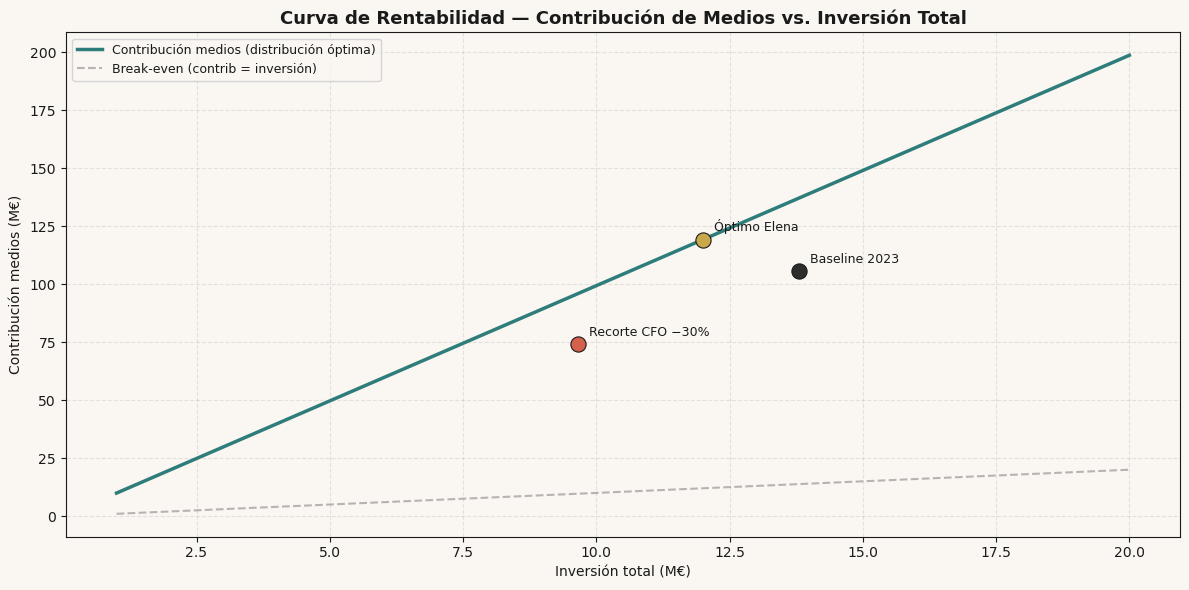

In [32]:
# ── 4.8 Curva de rentabilidad: contribución vs inversión total ───────────────
# Mantener la distribución óptima y escalar el total de 0 a 20M€
presupuestos = np.linspace(1_000_000, 20_000_000, 200)
contribs_curva = []
for total in presupuestos:
    alloc_temp = {c: pesos_elena.get(c, 0) * total for c in CANALES}
    contribs_curva.append(simulate_budget(alloc_temp)['contrib_medios'])

fig, ax = plt.subplots(figsize=(12, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.plot(presupuestos/1e6, np.array(contribs_curva)/1e6,
        color=TEAL, linewidth=2.5, label='Contribución medios (distribución óptima)')
ax.plot(presupuestos/1e6, presupuestos/1e6,
        color=GREY, linewidth=1.5, linestyle='--', alpha=0.6, label='Break-even (contrib = inversión)')

# Marcar los 3 escenarios
for esc in ESCENARIOS:
    ax.scatter(esc['result']['inv_total']/1e6, esc['result']['contrib_medios']/1e6,
               color=esc['color'], s=120, zorder=5, edgecolors=BLACK, linewidth=0.8)
    ax.annotate(esc['nombre'],
                (esc['result']['inv_total']/1e6, esc['result']['contrib_medios']/1e6),
                textcoords='offset points', xytext=(8, 6), fontsize=9, color=BLACK)

ax.set_title('Curva de Rentabilidad — Contribución de Medios vs. Inversión Total',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_xlabel('Inversión total (M€)')
ax.set_ylabel('Contribución medios (M€)')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('proyeccion_rentabilidad')
plt.show()

  Guardada: img/mroi_marginal_por_canal_v001.png


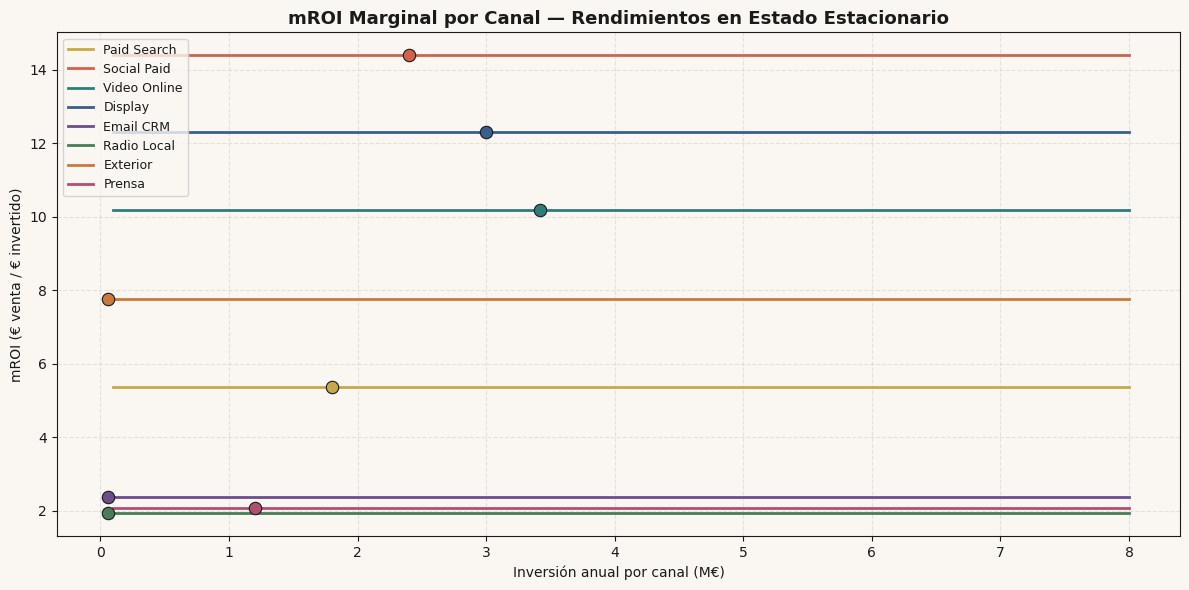

In [33]:
# ── 4.9 mROI marginal — curva de rendimientos decrecientes por canal ─────────
presupuestos_canal = np.linspace(100_000, 8_000_000, 150)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

for canal in CANALES_ACTIVOS:
    alpha_m = CANAL_PARAMS[canal]['alpha']
    beta_m  = BETAS[canal]
    mrois_c = []
    for inv in presupuestos_canal:
        inv_sem    = inv / N_SEMANAS
        adstock_ss = inv_sem / (1 - alpha_m)
        contrib    = beta_m * adstock_ss * N_SEMANAS
        mrois_c.append(contrib / inv)
    ax.plot(presupuestos_canal/1e6, mrois_c,
            color=CANAL_COLORS[canal], linewidth=2, label=canal)
    # Marcar el punto óptimo (Elena)
    inv_elena = alloc_elena[canal]
    if inv_elena > 0:
        inv_sem    = inv_elena / N_SEMANAS
        adstock_ss = inv_sem / (1 - alpha_m)
        mroi_pt    = beta_m * adstock_ss * N_SEMANAS / inv_elena
        ax.scatter(inv_elena/1e6, mroi_pt, color=CANAL_COLORS[canal],
                   s=80, zorder=5, edgecolors=BLACK, linewidth=0.8)

ax.set_title('mROI Marginal por Canal — Rendimientos en Estado Estacionario',
             fontsize=13, fontweight='bold', color=BLACK)
ax.set_xlabel('Inversión anual por canal (M€)')
ax.set_ylabel('mROI (€ venta / € invertido)')
ax.legend(fontsize=9)
fig.tight_layout()
guardar_img('mroi_marginal_por_canal')
plt.show()

## Bloque 4b — Análisis de sensibilidad (Tornado Chart)

¿Cuán robusto es el escenario óptimo ante incertidumbre en los betas estimados? Barrido de ±20% en cada β activo, midiendo el impacto en la contribución de medios del escenario Elena.


  Guardada: img/tornado_sensibilidad_beta_v001.png


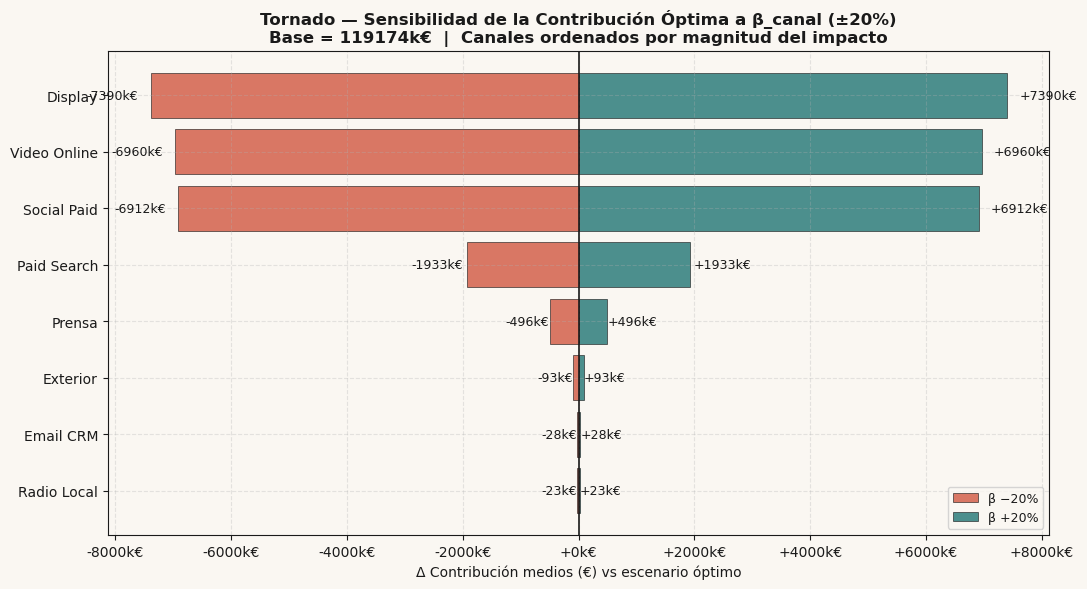


Canal más sensible: Display (rango ±20% β → 14780k€)
Canal menos sensible: Radio Local (rango ±20% β → 46k€)


In [34]:
# ── Tornado: sensibilidad de la contribución óptima a cada β ─────────────
DELTA = 0.20  # ±20%
base_contrib = r2['contrib_medios']

sens = []
for canal in CANALES_ACTIVOS:
    # Simular contrib con β_canal ±20% (manteniendo los demás fijos)
    beta_orig = BETAS[canal]
    # Helper inline
    def sim_with_beta(canal_mod, beta_mod):
        contrib = 0
        for c in CANALES:
            inv = alloc_elena[c]
            if inv == 0: continue
            b = beta_mod if c == canal_mod else BETAS[c]
            a = CANAL_PARAMS[c]['alpha']
            contrib += b * (inv/N_SEMANAS) / (1 - a) * N_SEMANAS
        return contrib

    c_low  = sim_with_beta(canal, beta_orig * (1 - DELTA))
    c_high = sim_with_beta(canal, beta_orig * (1 + DELTA))
    sens.append({
        'canal':  canal,
        'low':    c_low  - base_contrib,
        'high':   c_high - base_contrib,
        'rango':  c_high - c_low,
    })

sens_df = pd.DataFrame(sens).sort_values('rango', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

y = np.arange(len(sens_df))
ax.barh(y, sens_df['low'],  color=CORAL, edgecolor=BLACK, linewidth=0.5, alpha=0.85, label=f'β −{DELTA:.0%}')
ax.barh(y, sens_df['high'], color=TEAL,  edgecolor=BLACK, linewidth=0.5, alpha=0.85, label=f'β +{DELTA:.0%}')

ax.axvline(0, color=BLACK, linewidth=1.2)
ax.set_yticks(y)
ax.set_yticklabels(sens_df['canal'].tolist(), fontsize=10)

# Etiquetas
for i, (_, row) in enumerate(sens_df.iterrows()):
    ax.text(row['low']  - abs(row['low'])*0.03,  i, f"{row['low']/1e3:+.0f}k€",
            va='center', ha='right', fontsize=9, color=BLACK)
    ax.text(row['high'] + abs(row['high'])*0.03, i, f"{row['high']/1e3:+.0f}k€",
            va='center', ha='left',  fontsize=9, color=BLACK)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:+.0f}k€'))
ax.set_title(f'Tornado — Sensibilidad de la Contribución Óptima a β_canal (±{DELTA:.0%})\n'
             f'Base = {base_contrib/1e3:.0f}k€  |  Canales ordenados por magnitud del impacto',
             fontsize=12, fontweight='bold', color=BLACK)
ax.set_xlabel('Δ Contribución medios (€) vs escenario óptimo')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
guardar_img('tornado_sensibilidad_beta')
plt.show()

print(f'\nCanal más sensible: {sens_df.iloc[-1]["canal"]} '
      f'(rango ±20% β → {sens_df.iloc[-1]["rango"]/1e3:.0f}k€)')
print(f'Canal menos sensible: {sens_df.iloc[0]["canal"]} '
      f'(rango ±20% β → {sens_df.iloc[0]["rango"]/1e3:.0f}k€)')


## Bloque 5 — Tabla de presupuesto óptimo 2024 y argumentario

In [35]:
# ── Tabla de redistribución ───────────────────────────────────────────────────
filas = []
for canal in CANALES:
    v_base  = alloc_baseline[canal]
    v_elena = alloc_elena[canal]
    delta_eur = v_elena - v_base
    delta_pct = (v_elena / v_base - 1) * 100 if v_base > 0 else float('nan')
    filas.append({
        'Canal':                  canal,
        'Presupuesto 2023 (€)':   v_base,
        'Presupuesto Óptimo 2024 (€)': v_elena,
        'Variación (€)':          delta_eur,
        'Variación (%)':          delta_pct,
        'mROI ss':                mroi_ss.get(canal, 0.0),
        'Peso% 12M€':             v_elena / PRESUPUESTO_ELENA * 100,
        'Activo':                 canal in CANALES_ACTIVOS,
    })

# Fila TOTAL
filas.append({
    'Canal':                  'TOTAL',
    'Presupuesto 2023 (€)':   TOTAL_BASELINE,
    'Presupuesto Óptimo 2024 (€)': PRESUPUESTO_ELENA,
    'Variación (€)':          PRESUPUESTO_ELENA - TOTAL_BASELINE,
    'Variación (%)':          (PRESUPUESTO_ELENA / TOTAL_BASELINE - 1) * 100,
    'mROI ss':                None,
    'Peso% 12M€':             100.0,
    'Activo':                 None,
})

df_presupuesto = pd.DataFrame(filas)
out_path = os.path.join(OUT_DIR, 'presupuesto_optimo_2024.csv')
df_presupuesto.to_csv(out_path, index=False)
print(f'✓ presupuesto_optimo_2024.csv guardado')

# Mostrar formateado
fmt = df_presupuesto.copy()
fmt['Presupuesto 2023 (€)']        = fmt['Presupuesto 2023 (€)'].map(lambda x: f'{x:>13,.0f}€')
fmt['Presupuesto Óptimo 2024 (€)'] = fmt['Presupuesto Óptimo 2024 (€)'].map(lambda x: f'{x:>13,.0f}€')
fmt['Variación (€)']               = fmt['Variación (€)'].map(lambda x: f'{x:>+13,.0f}€')
fmt['Variación (%)']               = fmt['Variación (%)'].map(lambda x: f'{x:>+7.1f}%' if x == x else '—')
fmt['mROI ss']                     = fmt['mROI ss'].map(lambda x: f'{x:.4f}x' if x and x == x else '—')
fmt['Peso% 12M€']                  = fmt['Peso% 12M€'].map(lambda x: f'{x:>6.1f}%')
fmt['Activo']                      = fmt['Activo'].map(lambda x: '✓' if x is True else ('✗' if x is False else '—'))
print()
print(fmt.to_string(index=False))

✓ presupuesto_optimo_2024.csv guardado

       Canal Presupuesto 2023 (€) Presupuesto Óptimo 2024 (€)  Variación (€) Variación (%)  mROI ss Peso% 12M€ Activo
 Paid Search           3,126,606€                  1,800,000€    -1,326,606€        -42.4%  5.3690x      15.0%      ✓
 Social Paid           2,375,151€                  2,400,000€       +24,849€         +1.0% 14.3997x      20.0%      ✓
Video Online           2,072,352€                  3,420,000€    +1,347,648€        +65.0% 10.1749x      28.5%      ✓
     Display           1,106,104€                  3,000,000€    +1,893,896€       +171.2% 12.3168x      25.0%      ✓
   Email CRM             688,954€                     60,000€      -628,954€        -91.3%  2.3688x       0.5%      ✓
 Radio Local           1,529,937€                     60,000€    -1,469,937€        -96.1%  1.9288x       0.5%      ✓
    Exterior           1,650,855€                     60,000€    -1,590,855€        -96.4%  7.7683x       0.5%      ✓
      Prensa    

  Guardada: img/heatmap_presupuesto_recomendado_v001.png


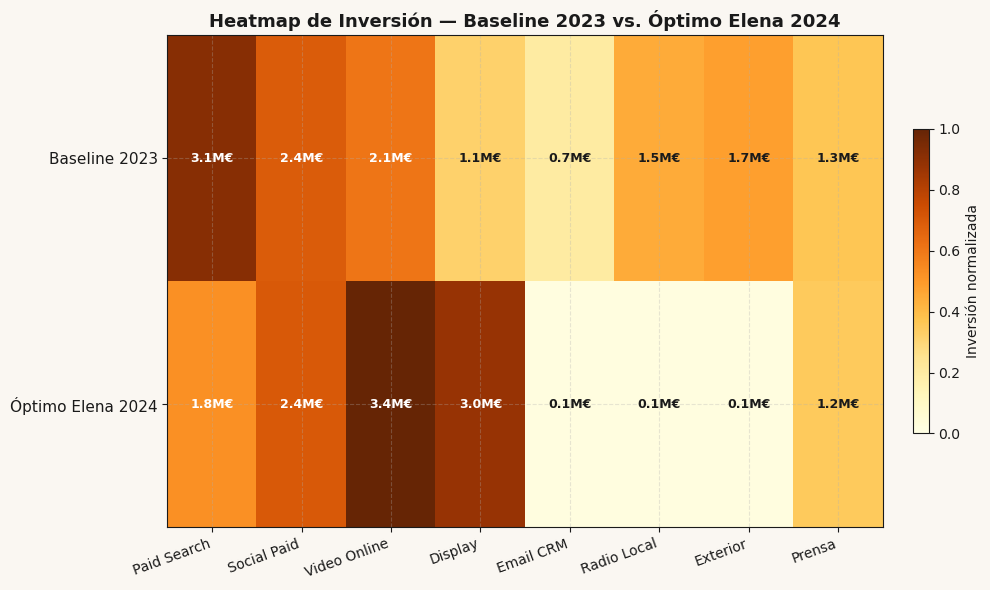

In [36]:
# ── 5.1 Heatmap de variaciones de presupuesto ─────────────────────────────────
df_heat = df_presupuesto[df_presupuesto['Canal'] != 'TOTAL'].copy()
heat_cols = ['Presupuesto 2023 (€)', 'Presupuesto Óptimo 2024 (€)']
heat_vals = df_heat[heat_cols].values
heat_norm = heat_vals / heat_vals.max()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

im = ax.imshow(heat_norm.T, cmap='YlOrBr', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(df_heat)))
ax.set_xticklabels(df_heat['Canal'].tolist(), rotation=20, ha='right', fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Baseline 2023', 'Óptimo Elena 2024'], fontsize=11)

for j, (_, row) in enumerate(df_heat.iterrows()):
    for i, col in enumerate(heat_cols):
        val = row[col]
        norm_v = val / heat_vals.max()
        color_txt = 'white' if norm_v > 0.5 else BLACK
        ax.text(j, i, f'{val/1e6:.1f}M€', ha='center', va='center',
                fontsize=9, color=color_txt, fontweight='bold')

ax.set_title('Heatmap de Inversión — Baseline 2023 vs. Óptimo Elena 2024',
             fontsize=13, fontweight='bold', color=BLACK)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04, label='Inversión normalizada')
fig.tight_layout()
guardar_img('heatmap_presupuesto_recomendado')
plt.show()

In [37]:
# ── 5.2 Argumentario ejecutivo para Ricardo Sanz ────────────────────────────
delta_cfo_pct   = (r1['contrib_medios'] - r0['contrib_medios']) / r0['contrib_medios'] * 100
delta_elena_pct = (r2['contrib_medios'] - r0['contrib_medios']) / r0['contrib_medios'] * 100
ahorro_elena    = TOTAL_BASELINE - PRESUPUESTO_ELENA

print('═' * 72)
print('  ARGUMENTARIO EJECUTIVO — ELENA TORRES → RICARDO SANZ')
print('═' * 72)
print()
print('  PUNTO 1 — El recorte del -30% destruye valor desproporcionadamente')
print(f'    Inversión recortada: -{TOTAL_BASELINE*RECORTE/1e6:.1f}M€ '
      f'({TOTAL_BASELINE/1e6:.1f}M€ → {r1["inv_total"]/1e6:.1f}M€)')
print(f'    Pérdida de contribución: {delta_cfo_pct:+.1f}% '
      f'(−{(r0["contrib_medios"]-r1["contrib_medios"])/1e3:.0f}k€ en ventas atribuidas)')
print(f'    La pérdida de ventas es proporcional al recorte: no hay eficiencia')
print()
print('  PUNTO 2 — La redistribución óptima mejora el retorno con MENOS presupuesto')
print(f'    Inversión óptima: {PRESUPUESTO_ELENA/1e6:.0f}M€ '
      f'(ahorro de {ahorro_elena/1e6:.1f}M€ vs baseline)')
print(f'    Contribución medios: {delta_elena_pct:+.1f}% '
      f'(+{(r2["contrib_medios"]-r0["contrib_medios"])/1e3:.0f}k€ vs baseline)')
print(f'    mROI mejora: {r0["mroi_sim"]:.4f}x → {r2["mroi_sim"]:.4f}x '
      f'(+{(r2["mroi_sim"]/r0["mroi_sim"]-1)*100:.1f}%)')
print()
print('  PUNTO 3 — Los canales purgados por Lasso no deben recibir inversión')
print(f'    Lasso identificó como no significativos: {CANALES_PURGADOS}')
print(f'    Reasignar ese presupuesto a los canales activos: {CANALES_ACTIVOS}')
print(f'    maximiza la contribución incremental dentro del presupuesto disponible.')
print()
# Canal estrella: el activo con mayor mROI estacionario
canal_top = max(CANALES_ACTIVOS, key=lambda c: mroi_ss[c])
print(f'  PUNTO 4 — Canal estrella: {canal_top}')
print(f'    mROI {canal_top}: {mroi_ss[canal_top]:.4f}x '
      f'(1€ invertido → {mroi_ss[canal_top]:.4f}€ en ventas atribuidas)')
print(f'    Asignación óptima: {alloc_elena[canal_top]/1e6:.2f}M€ '
      f'({alloc_elena[canal_top]/PRESUPUESTO_ELENA*100:.1f}% del presupuesto total)')
print()
print('  RANKING mROI canales activos:')
for c in sorted(CANALES_ACTIVOS, key=lambda x: mroi_ss[x], reverse=True):
    print(f'    {c:<18} mROI={mroi_ss[c]:.4f}x  → {alloc_elena[c]/1e6:.2f}M€ '
          f'({alloc_elena[c]/PRESUPUESTO_ELENA*100:.1f}%)')
print()
print('═' * 72)

════════════════════════════════════════════════════════════════════════
  ARGUMENTARIO EJECUTIVO — ELENA TORRES → RICARDO SANZ
════════════════════════════════════════════════════════════════════════

  PUNTO 1 — El recorte del -30% destruye valor desproporcionadamente
    Inversión recortada: -4.1M€ (13.8M€ → 9.7M€)
    Pérdida de contribución: -30.0% (−31706k€ en ventas atribuidas)
    La pérdida de ventas es proporcional al recorte: no hay eficiencia

  PUNTO 2 — La redistribución óptima mejora el retorno con MENOS presupuesto
    Inversión óptima: 12M€ (ahorro de 1.8M€ vs baseline)
    Contribución medios: +12.8% (+13488k€ vs baseline)
    mROI mejora: 7.6584x → 9.9312x (+29.7%)

  PUNTO 3 — Los canales purgados por Lasso no deben recibir inversión
    Lasso identificó como no significativos: []
    Reasignar ese presupuesto a los canales activos: ['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM', 'Radio Local', 'Exterior', 'Prensa']
    maximiza la contribució

## Bloque 5b — Explorador Interactivo de mROI

Gráficas interactivas para explorar el rendimiento de los canales por año y simular presupuestos alternativos con optimización Simplex en tiempo real.


In [38]:
# ── 5b.1 Explorador de mROI histórico (Plotly interactivo) ───────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pre-computar datos anuales por canal
df_m = pd.read_parquet(os.path.join(DATA_DIR, 'df_model.parquet'))
df_m['semana_dt'] = pd.to_datetime(df_m['semana_dt'])
df_m = df_m.sort_values('semana_dt').reset_index(drop=True)
df_m['anio'] = df_m['semana_dt'].dt.year

df_inv_raw = pd.read_parquet(os.path.join(DATA_DIR, 'df_inversion_clean.parquet'))
df_inv_raw['anio'] = pd.to_datetime(df_inv_raw['semana_dt']).dt.year

ANIOS = sorted(df_m['anio'].unique())

anual = {}
for anio in ANIOS:
    mask_m = df_m['anio'] == anio
    mask_i = df_inv_raw['anio'] == anio
    for canal in CANALES:
        col  = ADSTOCK_MAP[canal]
        beta = BETAS[canal]
        inv  = float(df_inv_raw.loc[mask_i, canal].sum())
        adst = float(df_m.loc[mask_m, col].sum())
        contrib = beta * adst
        mroi = contrib / inv if inv > 0 else 0
        anual[(anio, canal)] = {'inv': inv, 'contrib': contrib, 'mroi': mroi}

# Opciones de dropdown: Total + cada canal activo + cada purgado
opciones = ['Total'] + CANALES_ACTIVOS + CANALES_PURGADOS

CREAM2='#FAF7F2'; BLACK2='#1A1A1A'

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Pre-crear 3 traces por opción (inv bars, contrib bars, mroi line)
n_traces_per = 3
all_traces = []

for opt in opciones:
    if opt == 'Total':
        inv_vals    = [sum(anual[(a,c)]['inv']     for c in CANALES) for a in ANIOS]
        contrib_vals= [sum(anual[(a,c)]['contrib'] for c in CANALES) for a in ANIOS]
        mroi_vals   = [c/i if i>0 else 0 for c,i in zip(contrib_vals, inv_vals)]
    else:
        inv_vals    = [anual[(a,opt)]['inv']     for a in ANIOS]
        contrib_vals= [anual[(a,opt)]['contrib'] for a in ANIOS]
        mroi_vals   = [anual[(a,opt)]['mroi']    for a in ANIOS]

    visible = (opt == 'Total')
    x_labels = [str(a) for a in ANIOS]

    fig.add_trace(go.Bar(
        x=x_labels, y=inv_vals,
        name='Inversión', marker_color=BLUE, opacity=0.7,
        text=[f'{v/1e6:.2f}M€' for v in inv_vals], textposition='outside',
        visible=visible, showlegend=(opt=='Total'),
        hovertemplate='<b>Inversión %{x}</b>: %{y:,.0f}€<extra></extra>',
    ), secondary_y=False)

    fig.add_trace(go.Bar(
        x=x_labels, y=contrib_vals,
        name='Contribución medios', marker_color=GOLD, opacity=0.85,
        text=[f'{v/1e6:.2f}M€' for v in contrib_vals], textposition='outside',
        visible=visible, showlegend=(opt=='Total'),
        hovertemplate='<b>Contribución %{x}</b>: %{y:,.0f}€<extra></extra>',
    ), secondary_y=False)

    fig.add_trace(go.Scatter(
        x=x_labels, y=mroi_vals,
        name='mROI', mode='lines+markers+text',
        line=dict(color=CORAL, width=3), marker=dict(size=10, color=CORAL),
        text=[f'{v:.3f}x' for v in mroi_vals], textposition='top center',
        textfont=dict(size=11, color=CORAL),
        visible=visible, showlegend=(opt=='Total'),
        hovertemplate='<b>mROI %{x}</b>: %{y:.4f}x<extra></extra>',
    ), secondary_y=True)

# Dropdown buttons
buttons = []
for i, opt in enumerate(opciones):
    vis = [False] * (len(opciones) * n_traces_per)
    vis[i*n_traces_per]   = True   # inv
    vis[i*n_traces_per+1] = True   # contrib
    vis[i*n_traces_per+2] = True   # mroi

    estado = ''
    if opt != 'Total':
        if opt in CANALES_ACTIVOS:
            estado = f' (β={BETAS[opt]:.2f}, α={CANAL_PARAMS[opt]["alpha"]})'
        else:
            estado = ' (purgado por Lasso)'

    buttons.append(dict(
        label=opt,
        method='update',
        args=[{'visible': vis},
              {'title.text': f'Explorador de mROI — {opt}{estado}'}]
    ))

fig.update_layout(
    paper_bgcolor=CREAM2, plot_bgcolor=CREAM2,
    font=dict(family='sans-serif', color=BLACK2),
    title=dict(text='Explorador de mROI — Total', x=0.5, font=dict(size=15)),
    updatemenus=[dict(
        type='dropdown',
        x=0.02, y=1.18, xanchor='left', yanchor='top',
        buttons=buttons,
        bgcolor=CREAM2, bordercolor='#888', borderwidth=1,
        font=dict(size=11),
        active=0,
    )],
    barmode='group',
    yaxis=dict(title='Inversión / Contribución (€)', tickformat=',.0f',
               gridcolor='#E0DDD8'),
    yaxis2=dict(title='mROI (€ venta / € invertido)', tickformat='.3f',
                gridcolor='#E0DDD8', overlaying='y', side='right',
                showgrid=False),
    xaxis=dict(gridcolor='#E0DDD8'),
    height=550, hovermode='x unified',
    legend=dict(bgcolor=CREAM2, bordercolor='#888', borderwidth=1,
                x=0.5, y=-0.12, xanchor='center', orientation='h'),
)
fig.show()


In [39]:
# ── 5b.2 Simulador de presupuesto con Simplex (Plotly + slider) ──────────────
from scipy.optimize import linprog as _linprog

# Pre-computar Simplex para cada nivel de presupuesto (6M → 20M, paso 500k)
BUDGETS = list(range(6_000_000, 20_500_000, 500_000))
n_act   = len(CANALES_ACTIVOS)
_c_lp   = np.array([-mroi_ss[c] for c in CANALES_ACTIVOS])
_A_lp   = np.ones((1, n_act))

sim_results = []
for budget in BUDGETS:
    _bounds = [(COTAS[c][0]*budget, COTAS[c][1]*budget) for c in CANALES_ACTIVOS]
    _res    = _linprog(_c_lp, A_ub=_A_lp, b_ub=np.array([budget]),
                       bounds=_bounds, method='highs')
    alloc_opt = {c: _res.x[i] for i, c in enumerate(CANALES_ACTIVOS)}
    contrib   = -_res.fun
    mroi_total= contrib / budget
    sim_results.append({
        'budget':  budget,
        'alloc':   alloc_opt,
        'contrib': contrib,
        'mroi':    mroi_total,
        'margen':  contrib * MARGEN_MEDIO,
    })

fig = go.Figure()

# Una traza de barras por nivel de presupuesto (solo la primera visible)
for j, sr in enumerate(sim_results):
    alloc_vals = [sr['alloc'].get(c, 0) for c in CANALES_ACTIVOS]
    fig.add_trace(go.Bar(
        x=CANALES_ACTIVOS,
        y=alloc_vals,
        marker_color=[CANAL_COLORS[c] for c in CANALES_ACTIVOS],
        marker_line=dict(color=BLACK, width=0.5),
        text=[f'{v/1e6:.2f}M€<br>({v/sr["budget"]*100:.0f}%)' for v in alloc_vals],
        textposition='outside',
        textfont=dict(size=10),
        visible=(j == 12),  # 12M€ por defecto (índice 12)
        hovertemplate='<b>%{x}</b><br>%{y:,.0f}€<br>%{text}<extra></extra>',
        showlegend=False,
    ))

# Slider steps
steps = []
for j, sr in enumerate(sim_results):
    vis = [False]*len(sim_results)
    vis[j] = True
    step = dict(
        method='update',
        label=f'{sr["budget"]/1e6:.1f}M',
        args=[
            {'visible': vis},
            {'title.text': (
                f'Simulador Simplex — Presupuesto: {sr["budget"]/1e6:.1f}M€  |  '
                f'Contribución: {sr["contrib"]/1e6:.2f}M€  |  '
                f'mROI: {sr["mroi"]:.3f}x  |  '
                f'Margen: {sr["margen"]/1e6:.2f}M€'
            )}
        ]
    )
    steps.append(step)

sr12 = sim_results[12]
fig.update_layout(
    paper_bgcolor=CREAM, plot_bgcolor=CREAM,
    font=dict(family='sans-serif', color=BLACK),
    title=dict(
        text=(f'Simulador Simplex — Presupuesto: {sr12["budget"]/1e6:.1f}M€  |  '
              f'Contribución: {sr12["contrib"]/1e6:.2f}M€  |  '
              f'mROI: {sr12["mroi"]:.3f}x  |  '
              f'Margen: {sr12["margen"]/1e6:.2f}M€'),
        x=0.5, font=dict(size=14)),
    sliders=[dict(
        active=12,
        pad=dict(t=60, b=10),
        currentvalue=dict(prefix='Presupuesto total: ', suffix='€',
                          font=dict(size=14, color=BLACK)),
        steps=steps,
        bgcolor=CREAM, bordercolor='#888',
    )],
    yaxis=dict(title='Asignación óptima por canal (€)', tickformat=',.0f',
               gridcolor='#E0DDD8',
               range=[0, max(max(sr['alloc'].values()) for sr in sim_results)*1.3]),
    xaxis=dict(tickangle=-15, gridcolor='#E0DDD8'),
    height=550,
)

# Añadir anotación de contexto
fig.add_annotation(
    text='Cada posición del slider recalcula la optimización Simplex<br>'
         'Los canales purgados (Email CRM, Radio Local, Exterior) reciben siempre 0€',
    xref='paper', yref='paper', x=0.5, y=-0.15,
    showarrow=False, font=dict(size=10, color='#888'),
)
fig.show()


## Bloque 6 — Verificaciones finales

In [40]:
checks = []

# 1. simulate_budget devuelve resultados coherentes
checks.append(('simulate_budget() retorna dict con 6 claves',
               set(r0.keys()) == {'inv_total','contrib_medios','margen_incr','mroi_sim','payback','detalle'}))

# 2. Recorte CFO da contrib menor que baseline
checks.append(('Recorte CFO → contrib < baseline',
               r1['contrib_medios'] < r0['contrib_medios']))

# 3. Óptimo Elena da contrib mayor que baseline
checks.append(('Óptimo Elena → contrib > baseline',
               r2['contrib_medios'] > r0['contrib_medios']))

# 4. Suma óptimo Elena = 12M€
suma_elena = sum(alloc_elena.values())
checks.append((f'Σ alloc_elena = 12M€ (actual: {suma_elena/1e6:.2f}M€)',
               abs(suma_elena - PRESUPUESTO_ELENA) < 1))

# 5. Canales purgados reciben 0€ en óptimo
purgados_cero = all(alloc_elena[c] == 0 for c in CANALES_PURGADOS)
checks.append(('Canales purgados reciben 0€ en óptimo', purgados_cero))

# 6. mROI óptimo > mROI baseline
checks.append(('mROI óptimo > mROI baseline',
               r2['mroi_sim'] > r0['mroi_sim']))

# 7. presupuesto_optimo_2024.csv exportado
checks.append(('presupuesto_optimo_2024.csv exportado',
               os.path.exists(out_path)))

# 8. Imágenes generadas
imgs = [f for f in os.listdir(IMG_DIR) if f.endswith('.png')]
checks.append((f'Imágenes generadas en img/ ({len(imgs)} total)', len(imgs) > 0))

print('═' * 60)
print('  VERIFICACIONES FINALES — FASE 6')
print('═' * 60)
all_ok = True
for msg, ok in checks:
    estado = '✓' if ok else '✗'
    print(f'  {estado} {msg}')
    if not ok:
        all_ok = False
print('═' * 60)
print(f'  {"✓ FASE 6 COMPLETADA" if all_ok else "✗ Revisar checks fallidos"}')
print('═' * 60)

════════════════════════════════════════════════════════════
  VERIFICACIONES FINALES — FASE 6
════════════════════════════════════════════════════════════
  ✓ simulate_budget() retorna dict con 6 claves
  ✓ Recorte CFO → contrib < baseline
  ✓ Óptimo Elena → contrib > baseline
  ✓ Σ alloc_elena = 12M€ (actual: 12.00M€)
  ✓ Canales purgados reciben 0€ en óptimo
  ✓ mROI óptimo > mROI baseline
  ✓ presupuesto_optimo_2024.csv exportado
  ✓ Imágenes generadas en img/ (546 total)
════════════════════════════════════════════════════════════
  ✓ FASE 6 COMPLETADA
════════════════════════════════════════════════════════════
